# INX Future Inc Employee Performance

## Problem Statement.
INX Future Inc,(referred to as INX), is one of the leading data analytics and automation solution provider with over 15 years of global business experience. INX is consistently rated as top 20 best employer past 5 years. 

Recent years, the employee performance indexes are not healthy and this is becoming a growing concern among the top management. There has been increased escalations on service delivery and client satisfaction level came down by 8 percentage points. CEO, Mr. Brian, knows the issues but concerned to take any actions in penalizing non-performing employees as this would affect employee morale of all the employees in general and may further reduce the performance. Also, the market perception best employer and thereby attracting best talents to join the company. 

Mr. Brian decided to initiate a data science project , which analyses the current employee data and find the core underlying causes of this performance issues. Mr. Brian, being a data scientist himself, expects the findings of this project will help him to take right course of actions. He also expects a clear indicators of non performing employees, so that any penalization of non-performing employee, if required, may not significantly affect other employee morals.

## Project Objectives.
The primary goal of this data science project is to analyze INX Future Inc's employees data to uncover the root causes of recent decline in performance and client satisfaction. To guide the analysis and deliver actionable insights for top management, the project is structured around the following key objectives:

* Evaluate and compare performance indexes across different departments. 
* Determining the top 3 most critical factors affecting employee performance. 
* Develop and train a robust machine learning model capable of predicting employee performance based on input factors, serving as a data-driven tool for future hiring.
* Provide recommendations to improve overall employee performance based on insights from analysis.



### Importing Libraries.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
data = pd.read_csv('INX_Employee_Data.CSV')
data.head(10)

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3
5,E1001011,27,Male,Life Sciences,Divorced,Development,Developer,Travel_Frequently,10,2,...,3,9,4,2,9,7,1,7,No,4
6,E1001016,50,Male,Marketing,Married,Sales,Sales Representative,Travel_Rarely,8,4,...,4,4,2,3,2,2,2,2,No,3
7,E1001019,28,Female,Life Sciences,Single,Development,Developer,Travel_Rarely,1,2,...,4,10,4,3,7,7,3,7,Yes,3
8,E1001020,36,Female,Life Sciences,Married,Development,Developer,Non-Travel,8,3,...,1,10,2,3,8,7,0,5,No,3
9,E1001021,38,Female,Life Sciences,Single,Development,Developer,Travel_Rarely,1,3,...,4,10,4,4,1,0,0,0,No,3


In [3]:
df_definitions = pd.read_csv("Data_definitions.csv")
df_definitions.head(15)

,Unnamed: 0,Unnamed: 1
0,EmpEducationLevel,1 'Below College'
1,NaN,2 'College'
2,NaN,3 'Bachelor'
3,NaN,4 'Master'
4,NaN,5 'Doctor'
5,NaN,NaN
6,EmpEnvironmentSatisfaction,1 'Low'
7,NaN,2 'Medium'
8,NaN,3 'High'
9,NaN,4 'Very High'


In [4]:
data.columns

Index(['EmpNumber', 'Age', 'Gender', 'EducationBackground', 'MaritalStatus',
       'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency',
       'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction',
       'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel',
       'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition', 'PerformanceRating'],
      dtype='str')

## Meaning of Column Names.
0. EmpNumber - shows unique ID number of an employee.
1. Age - shows how old an employee is.
2. Gender - shows the sex of an employee.
3. Education Background - shows the specialization of each employee in which they studied. 
4. MaritalStatus - shows whether an employee is (Single, Married, Divorced)
5. EmpDepartment - shows the department in which an employee is working.
6. EmpJobRole - shows the role or position of an employee.
7. BusinessTravelFrequency - shows how many times an employee travels for the field or near clients.
8. DistanceFromHome - is how far the employee stays from the company.
9. EmpEducationLevel - is the highest level of an employee's education.
10. EmpEnvironmentSatisfaction - is a rating about the work culture or environment they work in. 
11. EmpHourlyRate - shows how much time employee work in a day.
12. EmpJobInvolvement - shows how employee are invested in their jobs.
13. EmpJobLevel - is the the employee position within the organization.
14. EmpJobSatisfaction - is the level of job satisfaction that employees experience in their current roles.
15. NumCompaniesWorked - shows how many companies the employee worked before.
16. OverTime - indicates whether an employee has worked past their regular hours.
17. EmpLastSalaryHikePercent - percentage increase in an employee's salary during their most recently salary hike.
18. EmpRelationshipSatisfaction- shows how well the employee relates with supervisors, team members, and colleagues.
19. TotalWorkExperienceInYears - shows the number of years of work experience of an employee accumulated throughout their career. 
20. TrainingTimesLastYear - the number of times an employee received training during the last year. 
21. EmpWorkLifeBalance - shows how well an employee can manage their profession and personal commitments.
22. ExperienceYearsAtThisCompany - is the number of years an employee has worked at their current company. 
23. ExperienceYearsInCurrentRole - represent the number of years an employee has spent in their current job role or position within the organization.
24. YearsSinceLastPromotion - shows the number of years that have elapsed since an employee's last promotion within the organisation.
25. YearsWithCurrManager - represents the number of years an employee has worked under their current manager. 
26. Attrition - determines whether an employee has left the organization or is still employed.
27. PerformanceRating - represents an employee's performance rating within the organization and is our Target class. 

## Exploratory Data Analysis (EDA)

In [ ]:
# the dataset columns are not visible, by using pd.set_option can make all the columns visible in the dataset.
pd.set_option('display.max_columns',None)

In [6]:
data.head(10)

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,4,55,3,2,4,1,No,12,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,4,42,3,2,1,2,No,12,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,4,48,2,3,1,5,Yes,21,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,2,73,2,5,4,3,No,15,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,1,84,3,2,1,8,No,14,4,10,1,3,2,2,2,2,No,3
5,E1001011,27,Male,Life Sciences,Divorced,Development,Developer,Travel_Frequently,10,2,4,32,3,3,1,1,No,21,3,9,4,2,9,7,1,7,No,4
6,E1001016,50,Male,Marketing,Married,Sales,Sales Representative,Travel_Rarely,8,4,4,54,3,1,2,7,No,15,4,4,2,3,2,2,2,2,No,3
7,E1001019,28,Female,Life Sciences,Single,Development,Developer,Travel_Rarely,1,2,1,67,1,1,2,7,Yes,13,4,10,4,3,7,7,3,7,Yes,3
8,E1001020,36,Female,Life Sciences,Married,Development,Developer,Non-Travel,8,3,1,63,4,3,1,9,No,14,1,10,2,3,8,7,0,5,No,3
9,E1001021,38,Female,Life Sciences,Single,Development,Developer,Travel_Rarely,1,3,3,81,3,3,3,4,Yes,14,4,10,4,4,1,0,0,0,No,3


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   EmpNumber                     1200 non-null   str  
 1   Age                           1200 non-null   int64
 2   Gender                        1200 non-null   str  
 3   EducationBackground           1200 non-null   str  
 4   MaritalStatus                 1200 non-null   str  
 5   EmpDepartment                 1200 non-null   str  
 6   EmpJobRole                    1200 non-null   str  
 7   BusinessTravelFrequency       1200 non-null   str  
 8   DistanceFromHome              1200 non-null   int64
 9   EmpEducationLevel             1200 non-null   int64
 10  EmpEnvironmentSatisfaction    1200 non-null   int64
 11  EmpHourlyRate                 1200 non-null   int64
 12  EmpJobInvolvement             1200 non-null   int64
 13  EmpJobLevel                   1200 non-null 

## Observations.
* The dataset contains 1200 entries. 
* There are a total of 28 columns, with 19 columns having "int64" (integers) data type and 9 columns being strings. 
* The dataset occupies approximately 262 KB of RAM. 

In [8]:
data.isnull().sum()

EmpNumber                       0
Age                             0
Gender                          0
EducationBackground             0
MaritalStatus                   0
EmpDepartment                   0
EmpJobRole                      0
BusinessTravelFrequency         0
DistanceFromHome                0
EmpEducationLevel               0
EmpEnvironmentSatisfaction      0
EmpHourlyRate                   0
EmpJobInvolvement               0
EmpJobLevel                     0
EmpJobSatisfaction              0
NumCompaniesWorked              0
OverTime                        0
EmpLastSalaryHikePercent        0
EmpRelationshipSatisfaction     0
TotalWorkExperienceInYears      0
TrainingTimesLastYear           0
EmpWorkLifeBalance              0
ExperienceYearsAtThisCompany    0
ExperienceYearsInCurrentRole    0
YearsSinceLastPromotion         0
YearsWithCurrManager            0
Attrition                       0
PerformanceRating               0
dtype: int64

## Observations.
* The dataset has no missing values.

In [9]:
data.duplicated().sum()

0

There are no duplicates in the dataset.

In [10]:
#.T (transpose) is used to flip the rows and columns of the DataFrame, making it easier to read the summary statistics for each column.
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1200.0,36.918333,9.087289,18.0,30.0,36.0,43.0,60.0
DistanceFromHome,1200.0,9.165833,8.176636,1.0,2.0,7.0,14.0,29.0
EmpEducationLevel,1200.0,2.892500,1.044120,1.0,2.0,3.0,4.0,5.0
EmpEnvironmentSatisfaction,1200.0,2.715833,1.090599,1.0,2.0,3.0,4.0,4.0
EmpHourlyRate,1200.0,65.981667,20.211302,30.0,48.0,66.0,83.0,100.0
EmpJobInvolvement,1200.0,2.731667,0.707164,1.0,2.0,3.0,3.0,4.0
EmpJobLevel,1200.0,2.067500,1.107836,1.0,1.0,2.0,3.0,5.0
EmpJobSatisfaction,1200.0,2.732500,1.100888,1.0,2.0,3.0,4.0,4.0
NumCompaniesWorked,1200.0,2.665000,2.469384,0.0,1.0,2.0,4.0,9.0
EmpLastSalaryHikePercent,1200.0,15.222500,3.625918,11.0,12.0,14.0,18.0,25.0


## Summary Statistics.
* **Count:** The dataset contains 1200 employee records with no missing values across all 19 numerical columns, proving that the dataset is clean.

* **Average Employee Age and Experience :** The average employee age is 36.9 (37) years old, with a standard deviation of 9.09 with a range of (18-60) showing a fairly symmetric distribution centered around the median of 36. 
TotalWorkExperienceInYears average is 11.3 years with a median of 10 years, while experience at the current company averages 7.1 years indicating that most joined the organization mid-career. The right-skewed nature of both the experience features (mean>median), suggests the presence of a small group of long-serving employees, with maximum reaching 40 years.

* **Scale Difference:** Some columns have small scales from 1 to 4 (like EmpJobSatisfaction or EmpWorkLifeBalance), while other have big numbers (like EmpHourlyRate ranging from 30 to 100, or ExperienceYearsAtThisCompany going up to 40). Because of this standardization of the data will be done before modelling so that no single feature dominates because of its size.

* **Some Employees are stuck in their roles:** YearsSinceLastPromotion is positively skewed since the mean (2.19) is greater than median (1).The 75th percentile is 3,meaning a good number of employees received a promotion within the last three years. However, the maximum number is 15 years without a promotion, and at least 25% of employees have never been promoted at all (25th percentile is 0). This shows a specific group of people have been stuck in the same spot for a long time. 

* **High Variability in some features:** DistanceFromHome and NumCompaniesWorked are highly spread out relative to their averages. 50% of employees lives about 7km from work, some live as far as 29km from work. This shows how spread out this feature is. Similarly, most employees have worked at 1 or 2 companies before but there are employees who have worked at up to 9 companies before.

* **Performance Rating - Target Variable:** It ranges from 2 to 4 with a mean of 2.95 and a very low standard deviation of 0.5. Given that median, 25th, and 75th percentiles equal to 3, most of the employees are rated at level 3. This means the target variable is highly imbalanced.

In [11]:
# statistical analysis of string columns in the dataset.
data.describe(include='object').T

,count,unique,top,freq
EmpNumber,1200,1200,E1001000,1
Gender,1200,2,Male,725
EducationBackground,1200,6,Life Sciences,492
MaritalStatus,1200,3,Married,548
EmpDepartment,1200,6,Sales,373
EmpJobRole,1200,19,Sales Executive,270
BusinessTravelFrequency,1200,3,Travel_Rarely,846
OverTime,1200,2,No,847
Attrition,1200,2,No,1022


## Observation from describe('object')
* This dataset has two genders with 725 males dominating and the rest being females.
* There are 6 types of educational background in which Life sciences is most common.
* Marital status has 3 types with married having a frequency of 548.
* There are 6 types of employee departments with sales having the highest count (373).
* Sales executive employment job role is taking the lead with 270 employees, however there are 19 job roles.
* There are three types of business travel frequency and travel_rarely is the most common one (846)
* Most employees don't work overtime.
* Majority of the employees do not have attrition records. "No" is the most frequent value (1022)

## Visualization

In [12]:
#dropping EmpNumber column as it is not useful for the analysis.
data.drop('EmpNumber', axis=1, inplace=True)

In [13]:
# count of performance ratings for each department.
#pd.crosstab() builds a two-dimensional grid (contigency table) that counts how categorical variables (EmpDepartment and PerformanceRating) are related to each other.
dep_count = pd.crosstab(data['EmpDepartment'], data['PerformanceRating'])
dep_count


PerformanceRating,2,3,4
EmpDepartment,,,
Data Science,1,17,2
Development,13,304,44
Finance,15,30,4
Human Resources,10,38,6
Research & Development,68,234,41
Sales,87,251,35


### Observation from the cross tab table.
- The numbers across the top (2,3,4) are the performance scores. 
- The rows are departments. 
- The Low performers are **Finance, sales and Research and development.** Rating 2 which means "Good" is the lowest score in this dataset. 
- Sales has the highest number of employees (87) sitting at level 2. 
- Research and development has 68 employees sitting at level 2. 
- Finance has 15 employees sitting at level 2. 
- At first glance, it looks like sales is the biggest problem because 87 is the biggest number. But finance has only a total of 49 employees, 15 out of its 49 employees (31%) scored a Level 2 rating. Meaning nearly 31% of their entire team is underperforming hence dragging its team average down to 2.77.

- The High performers are **Data Science and Development.** 
- Data Science has only one employee sitting at level 2 and 2 sitting at level 4 while for development majority of the employees are sitting at level 3 (304) and level 4 (44), pulling their mean all the way up to 3.08 making it the top-performing department at INX.

In [14]:
# grouping by department and finding the mean performance rating for each department.
#reset_index() used to reset the index of the resulting DataFrame after grouping, making it easier to work with the data.
dep_perf = data.groupby('EmpDepartment')['PerformanceRating'].mean().reset_index() 
dep_perf.sort_values(by='PerformanceRating', ascending=False, inplace=True)
dep_perf

,EmpDepartment,PerformanceRating
1,Development,3.085873
0,Data Science,3.050000
3,Human Resources,2.925926
4,Research & Development,2.921283
5,Sales,2.860590
2,Finance,2.775510


### Observation from Groupby
- Development and data science department emerge as the company's benchmark both scoring an average of 3.0 and above.
- Finance ranks as the lowest-performing department at INX with a 2.77 average closely followed by sales with a 2.86 average. 
- The summary ranking validates Mr. Brian's worries. The drop in performance isn't a company-wide problem. Instead it's happening in two specific areas Finance and Sales.

## 1. Performance Rating Distribution by Department

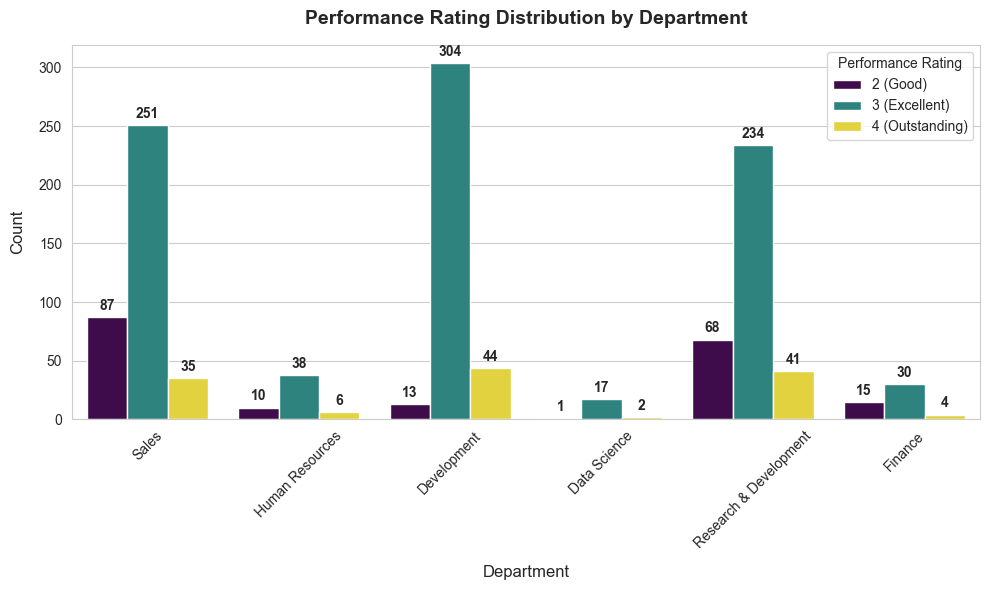

In [15]:
#setting the plotting size and style for better visualization.
plt.figure(figsize=(10,6))
sns.set_style('whitegrid')

ax = sns.countplot(
    data=data,
    x='EmpDepartment',
    hue='PerformanceRating',
    palette='viridis'
)

# writing the exact count on top ov every chart.
for container in ax.containers:
    ax.bar_label(container, fontsize=10, fontweight='bold', padding=3)

plt.title('Performance Rating Distribution by Department', fontsize=14, fontweight='bold', pad=15)# pad adding space between the title and the plot.
plt.xlabel('Department', fontsize=12, labelpad=10) # labelpad adding space between the x-axis label and the x-axis.
plt.ylabel('Count', fontsize=12, labelpad=10) # labelpad adding space between the y-axis label and the y-axis.
plt.xticks(rotation=45)
plt.legend(title='Performance Rating', labels =  ['2 (Good)', '3 (Excellent)', '4 (Outstanding)'])
plt.tight_layout()
plt.show()

### Observations
- The teal bars (Rating 3) are the tallest across all departments. This shows that most employees at the company are doing an excellent job. The biggest spike is in the Development team, which has a huge group of 304 employees.
- The purple bars (Rating 2) shows where the lower performance is. There are two very big purple peaks: Sales has 87 employees and Research and Development has 68 employees. Visually, these two departments hold the largest number of struggling employees.
- Finance has a high purple bar for its size. Even though the Finance department looks small on the graph, its purple bar (15 employees) is almost half the size of its teal bar (30 employees). This shows that a big percentage of this small team is struggling, which explains why their mean is so low.
- Rating 1 is missing completely. There are no bar graphs for a performance of rating 1. This proves that the dataset has no record for the lowest performance tier.

## 2. Correlation Matrix.

In [16]:
#separating the numeric and categorical columns in the dataset for further analysis.
num_cols = data.select_dtypes(include=['int64', 'float64'])
cat_cols = data.select_dtypes(include=['object'])
print("Numeric Columns:", num_cols.columns.tolist())
print("Categorical Columns:", cat_cols.columns.tolist())

Numeric Columns: ['Age', 'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel', 'EmpJobSatisfaction', 'NumCompaniesWorked', 'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction', 'TotalWorkExperienceInYears', 'TrainingTimesLastYear', 'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany', 'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'PerformanceRating']
Categorical Columns: ['Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency', 'OverTime', 'Attrition']


Mathematical Correlation with Performance Rating:
PerformanceRating               1.000000
EmpEnvironmentSatisfaction      0.395561
EmpLastSalaryHikePercent        0.333722
EmpWorkLifeBalance              0.124429
NumCompaniesWorked              0.020980
EmpEducationLevel               0.020529
EmpJobSatisfaction              0.000606
TrainingTimesLastYear          -0.005443
EmpJobInvolvement              -0.010539
EmpRelationshipSatisfaction    -0.019502
Age                            -0.040164
EmpHourlyRate                  -0.043116
DistanceFromHome               -0.046142
TotalWorkExperienceInYears     -0.068141
EmpJobLevel                    -0.076632
ExperienceYearsAtThisCompany   -0.111645
YearsWithCurrManager           -0.122313
ExperienceYearsInCurrentRole   -0.147638
YearsSinceLastPromotion        -0.167629
Name: PerformanceRating, dtype: float64


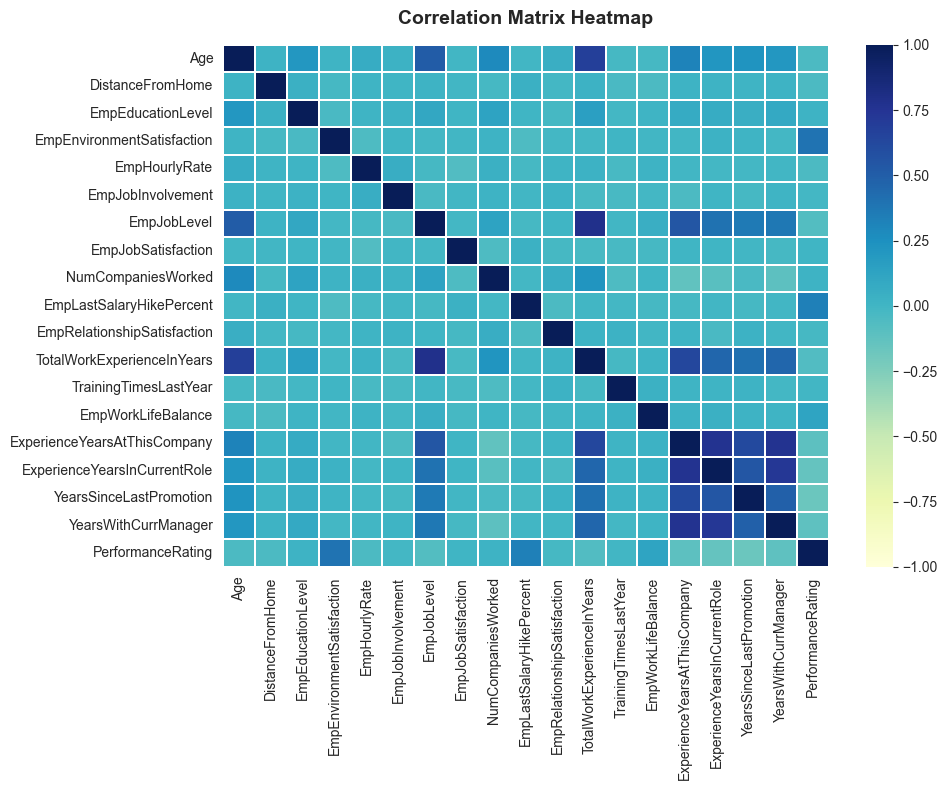

In [ ]:
# calculating the correlation matrix for the numeric columns in the dataset.
corr_matrix = num_cols.corr()

#printing the text list to show the correlation of each numeric column with the performance rating.
print('Mathematical Correlation with Performance Rating:')
print(corr_matrix['PerformanceRating'].sort_values(ascending=False))

# plotting the heatmap for the correlation matrix.
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=False, cmap='YlGnBu', vmin=-1, vmax=1, linewidths=0.1)

plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## Observations from Correlation Matrix
- Environment satisfaction (0.395) has the strongest positive correlation with performance ratings. This means employees who are comfortable and happy with their work environment consistently achieve higher performance scores. 
- Salary Hike Percentage emerges second with a positive correlation with Performance Ratings (0.333). It shows that giving employees bigger salary increases results to better performance ratings. 
- Work Life Balance is the third highest (0.124). It tells us that employees who maintain a good balance between their personal life and work tend to perform better on the job.

## 3. Visualizing the Top 3 Factors affecting employees performance. 

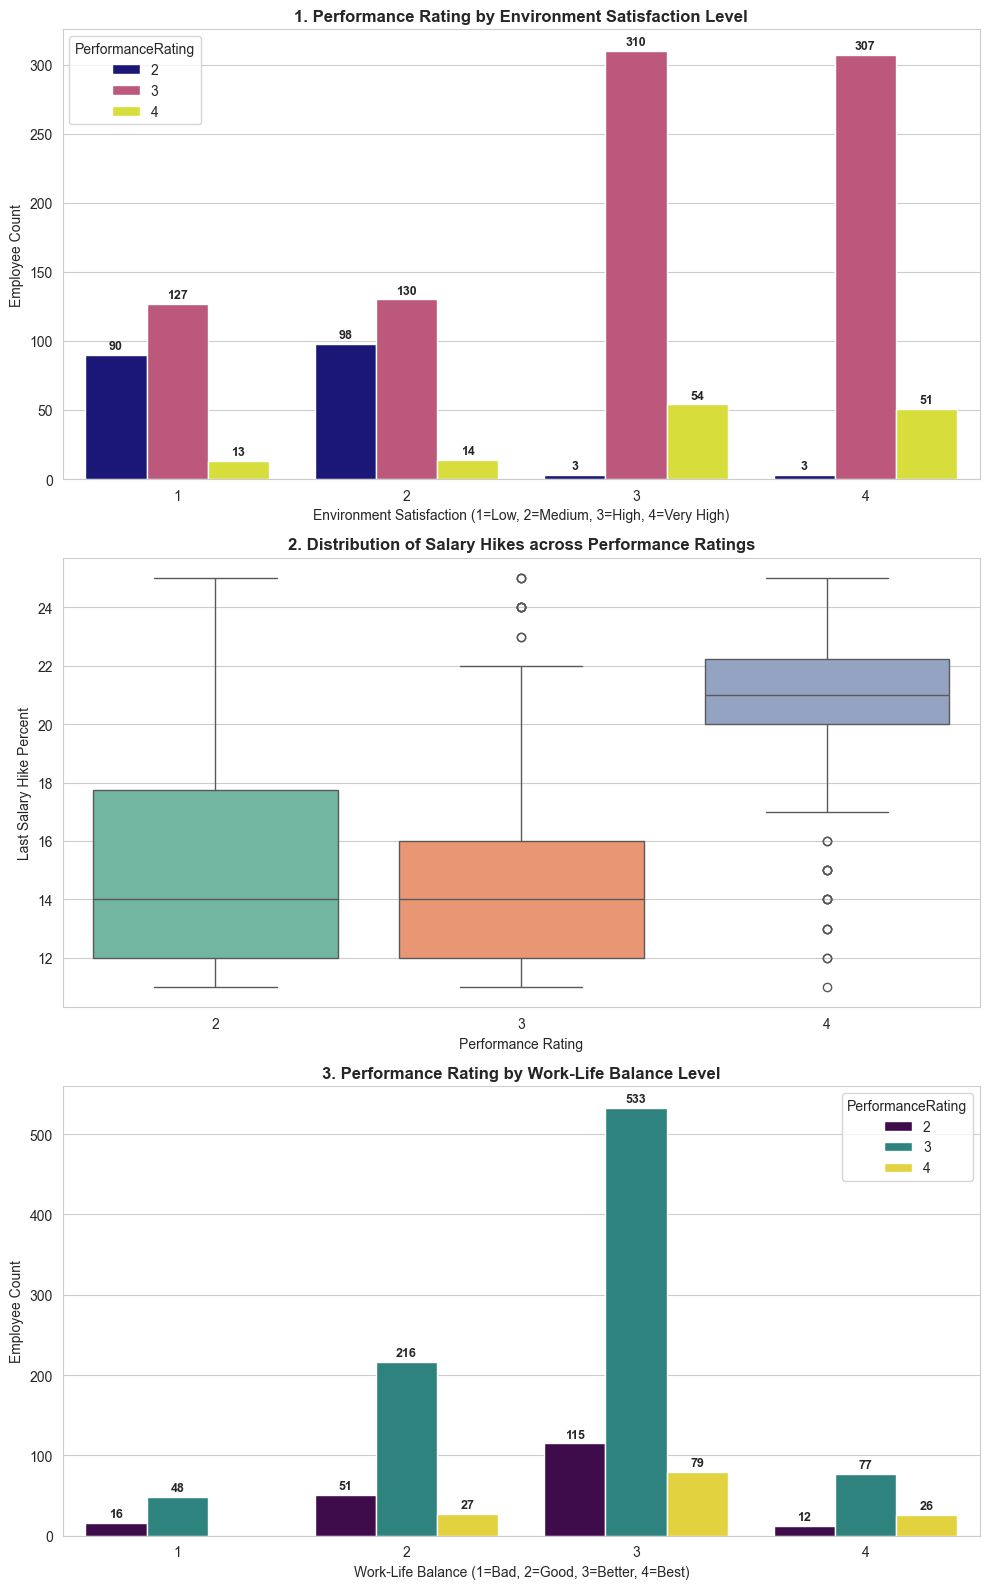

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 16))
sns.set_style("whitegrid")

# environment satisfaction
ax1 = sns.countplot(data=data, x='EmpEnvironmentSatisfaction', hue='PerformanceRating', ax=axes[0], palette='plasma')
for container in ax1.containers:
    ax1.bar_label(container, fontsize=9, fontweight='bold', padding=2)
axes[0].set_title('1. Performance Rating by Environment Satisfaction Level', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Environment Satisfaction (1=Low, 2=Medium, 3=High, 4=Very High)')
axes[0].set_ylabel('Employee Count')

#salary hike percentage.
sns.boxplot(data=data, x='PerformanceRating', y='EmpLastSalaryHikePercent', ax=axes[1], palette='Set2')
axes[1].set_title('2. Distribution of Salary Hikes across Performance Ratings', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Performance Rating')
axes[1].set_ylabel('Last Salary Hike Percent')

#work-life balance
ax3 = sns.countplot(data=data, x='EmpWorkLifeBalance', hue='PerformanceRating', ax=axes[2], palette='viridis')
for container in ax3.containers:
    ax3.bar_label(container, fontsize=9, fontweight='bold', padding=2)
axes[2].set_title('3. Performance Rating by Work-Life Balance Level', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Work-Life Balance (1=Bad, 2=Good, 3=Better, 4=Best)')
axes[2].set_ylabel('Employee Count')

plt.tight_layout()
plt.show()

## Observations.
1. Performance Rating by Environment Satisfaction Level
- When environment satisfaction is low (level 1), the number of low performers (Rating 2) is high. When satisfaction goes up to high (level 3), the number of low performers drops down to only 3 employees. At the same time, the high performers (Rating 3) jumps up to 310 people. This shows that a better working environment results to higher performance ratings.
2. Distribution of Salary Hikes across Performance Ratings.
- The box plot for rating 4 has outliers compared to ratings 2 and 3. Employees with a performance rating of 2 or 3 usually get a salary hike of around 14%. But for employees with a rating of 4, the salary hikes are much higher, between 20% and 22%. This proves that the highest performing employees are the ones getting salary increases above 20%.
3. Performance Rating by Work-Life Balance Level.
- Most employees in the company are grouped under level 3 (Better) work-life balance. At level 3 work-life balance,there is the largest group of top workers, with 533 employees at Rating 3 (Excellent) and 79 employees at Rating 4 (Outstanding). This shows that keeping a good work-life balance is where the largest number of successful employees are found. 


## 4. Overtime against Performance Rating.

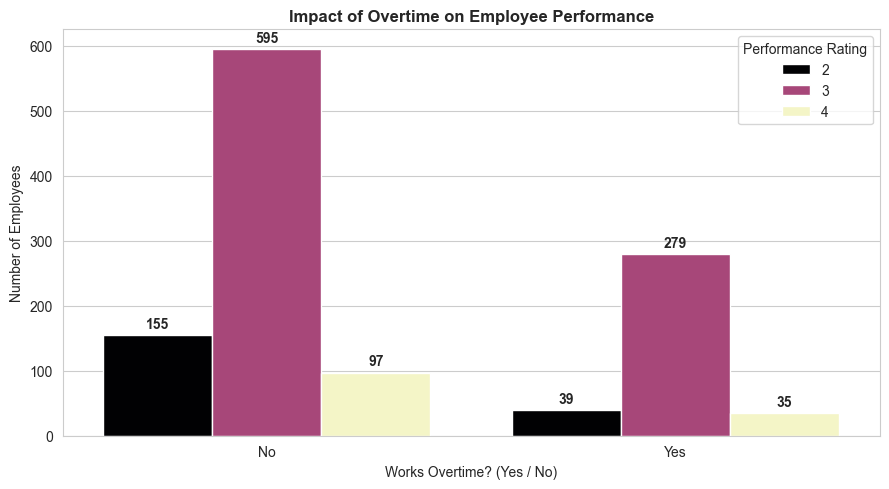

In [19]:
plt.figure(figsize=(9, 5))
sns.set_style("whitegrid")

# Plotting OverTime against PerformanceRating
ax = sns.countplot(data=data, x='OverTime', hue='PerformanceRating', palette='magma')
for container in ax.containers:
    ax.bar_label(container, fontsize=10, fontweight='bold', padding=3)

plt.title('Impact of Overtime on Employee Performance', fontsize=12, fontweight='bold')
plt.xlabel('Works Overtime? (Yes / No)')
plt.ylabel('Number of Employees')
plt.legend(title='Performance Rating')
plt.tight_layout()
plt.show()

## Observations.
For employees who do not work overtime, the largest group sits at at Rating 3 (Excellent) with 595 employees. The low performers Rating 2 (Good) are at 155 employees and the top performers rating 4 (outstanding) are at 97 employees. 
For employees who do work overtime, the numbers drop across all categories because it is a smaller group overall, 39 people at rating 2, 279 employees at rating 3 and 35 people at rating 4. 
This shows that working overtime does not automatically mean an employee will get a higher performance rating. In fact, most of the outstanding performers (Rating 4 ) come from the group that does not work overtime.

## Data Preprocessing

### 1. Outlier Detection and Handling.

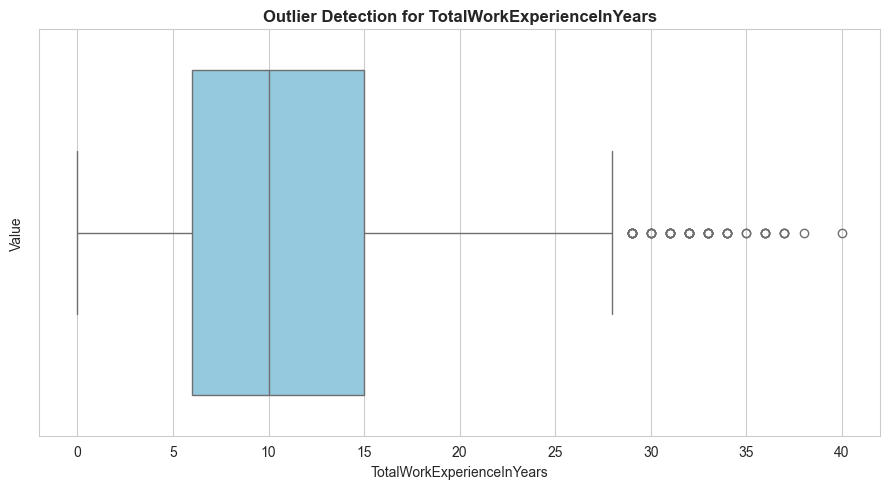

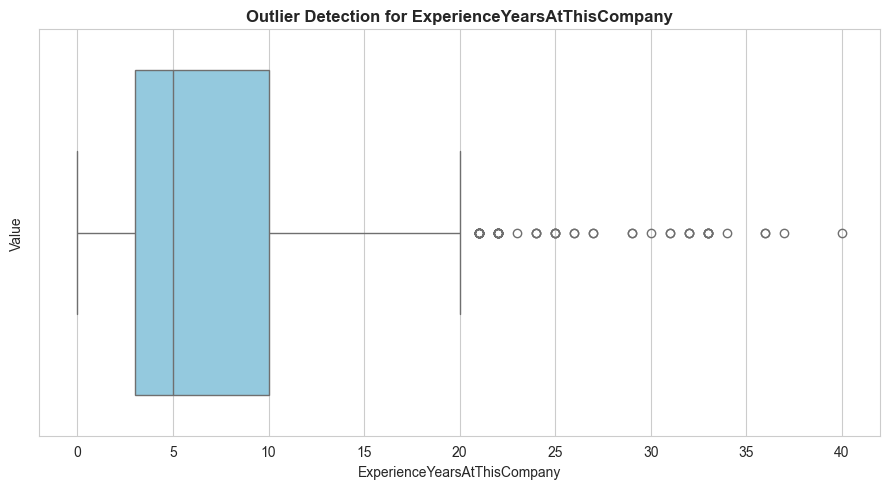

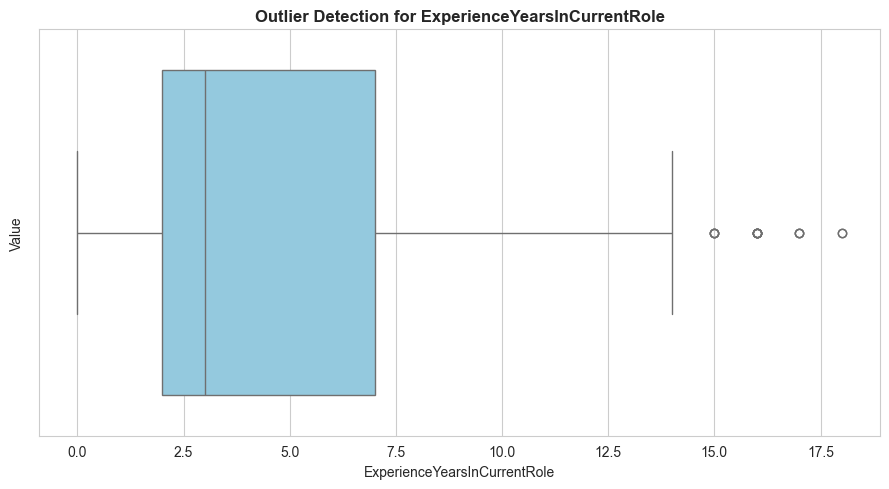

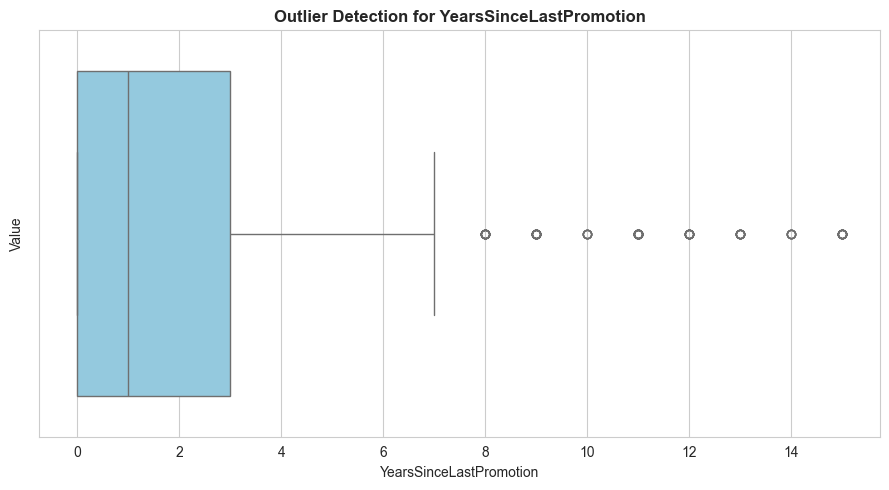

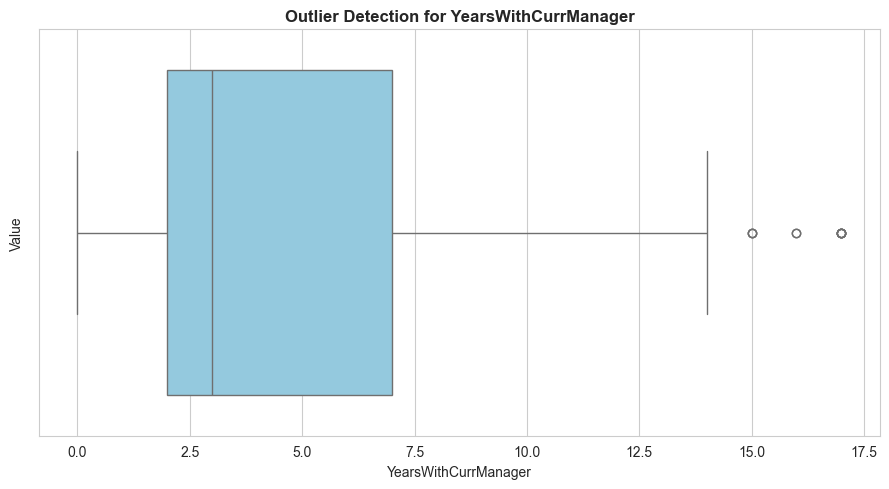

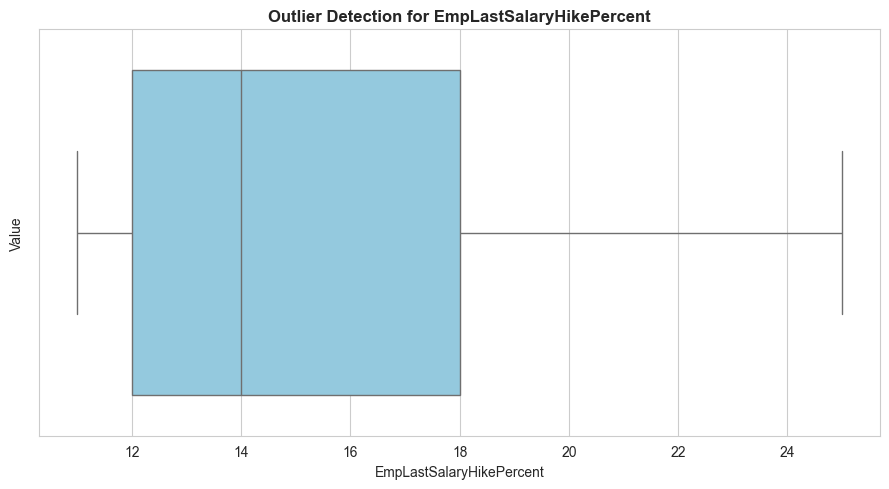

In [20]:
cols = [
    'TotalWorkExperienceInYears', 
    'ExperienceYearsAtThisCompany', 
    'ExperienceYearsInCurrentRole', 
    'YearsSinceLastPromotion', 
    'YearsWithCurrManager',
    'EmpLastSalaryHikePercent'
]

for col in cols:
    plt.figure(figsize=(9,5))
    sns.set_style('whitegrid')

    sns.boxplot(data=data, x=col, color='skyblue')
    plt.title(f'Outlier Detection for {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Value', fontsize=10)
    plt.tight_layout()
    plt.show()

## Observations on Outlier Detection and Handling.
- **TotalWorkExperienceInYears and ExperienceYearsAtThisCompany:** The charts display a distinct progression of data points extending past the 28 and 20-years mark, all the way up to 40 years. These are not data errors, they are simply long-serving employees whose experience is a crucial asset to the organization.
- **ExperienceYearsInCurrentRole and YearsWithCurrManager:** A small group of data points appears just beyond the upper whisker around the 15-year mark, some employees have simply been in the same role or under the same manager for a very long time
- **YearsSinceLastPromotion:** A steady sequence of data points extends up to 15 years — meaning some employees have gone over a decade without a promotion. That is a real problem worth flagging.
- **EmpLastSalaryHikePercent:** No outliers at all — every employee's salary hike falls within the 11% to 25% range. The data here is clean and consistent.

### 2. Data Encoding (Categorical Columns)
Machine learning models only understand numbers — they cannot process raw text like "Sales" or "Developer" directly. To fix this, I converted all categorical columns into numeric values.

In [21]:
#creating a copy of the original dataset.
encoded_data = data.copy()

#handling binary colums.
binary_cols = ['OverTime', 'Attrition']
for col in binary_cols:
    if col in encoded_data.columns:
        encoded_data[col] = encoded_data[col].map({'Yes': 1, 'No': 0})

#handling categorical columns using one-hot encoding.
rem_cat_cols = [col for col in cat_cols if col not in binary_cols]
print("Categorical Columns to Encode:", rem_cat_cols)

#applying one-hot encoding to the remaining categorical columns. 
#drop_first=true is used to avoid multicollinearity by dropping the first category of each column.
#pd.get_dummies() is used to convert categorical variables into dummy/indicator variables, creating new binary columns for each category in the original column.
encoded_data = pd.get_dummies(encoded_data, columns=rem_cat_cols, drop_first=True)
print("\nNew dataset shape after encoding:", encoded_data.shape)
encoded_data.head(5)

Categorical Columns to Encode: ['Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency']

New dataset shape after encoding: (1200, 54)


,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating,Gender_Male,EducationBackground_Life Sciences,EducationBackground_Marketing,EducationBackground_Medical,EducationBackground_Other,EducationBackground_Technical Degree,MaritalStatus_Married,MaritalStatus_Single,EmpDepartment_Development,EmpDepartment_Finance,EmpDepartment_Human Resources,EmpDepartment_Research & Development,EmpDepartment_Sales,EmpJobRole_Data Scientist,EmpJobRole_Delivery Manager,EmpJobRole_Developer,EmpJobRole_Finance Manager,EmpJobRole_Healthcare Representative,EmpJobRole_Human Resources,EmpJobRole_Laboratory Technician,EmpJobRole_Manager,EmpJobRole_Manager R&D,EmpJobRole_Manufacturing Director,EmpJobRole_Research Director,EmpJobRole_Research Scientist,EmpJobRole_Sales Executive,EmpJobRole_Sales Representative,EmpJobRole_Senior Developer,EmpJobRole_Senior Manager R&D,EmpJobRole_Technical Architect,EmpJobRole_Technical Lead,BusinessTravelFrequency_Travel_Frequently,BusinessTravelFrequency_Travel_Rarely
0,32,10,3,4,55,3,2,4,1,0,12,4,10,2,2,10,7,0,8,0,3,True,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True
1,47,14,4,4,42,3,2,1,2,0,12,4,20,2,3,7,7,1,7,0,3,True,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True
2,40,5,4,4,48,2,3,1,5,1,21,3,20,2,3,18,13,1,12,0,4,True,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False
3,41,10,4,2,73,2,5,4,3,0,15,2,23,2,2,21,6,12,6,0,3,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True
4,60,16,4,1,84,3,2,1,8,0,14,4,10,1,3,2,2,2,2,0,3,True,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True


### Observations. 
For binary columns like **OverTime** and **Attrition**, a direct binary mapping (0 and 1) was applied. For categorical columns with no inherent mathematical ranking (e.g., EmpJobRole),I applied One-Hot Encoding. This ensures that the algorithms do not mistakenly assume a sequential hierarchy among distinct categories.

**Original Dataset Dimensions:** 28 columns, **After Encoding Dataset Dimensions:** 54 columns.
The expansion of the feature space from 28 to 54 columns is the result of One-Hot Encoding. For instance, the original **EmpJobRole** column contained 19 unique job titles, One-Hot Encoding created a separate binary column for each title, dropping the first category to avoid redundancy. 

## 3. Training testing and splitting.

In [22]:
# separating the features and target variable for model training.
X = encoded_data.drop('PerformanceRating', axis=1)
y = encoded_data['PerformanceRating']

# training and testing the dataset using train_test_split from sklearn.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'X_train shape: {X_train.shape} |  y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape} |  y_test shape: {y_test.shape}')


X_train shape: (960, 53) |  y_train shape: (960,)
X_test shape: (240, 53) |  y_test shape: (240,)


## 4. Dimensionality Reduction

In [23]:
# Combining X_train and y_train temporarily to calculate correlations safely
train_data = X_train.copy()
train_data['PerformanceRating'] = y_train

#Calculating correlation matrix for all features with the target
corr_series = train_data.corr()['PerformanceRating'].sort_values(ascending=False)

#looking at the relationships clearly
print("Features with a Positive Correlation")
print(corr_series[corr_series > 0].to_string())


Features with a Positive Correlation
PerformanceRating                            1.000000
EmpEnvironmentSatisfaction                   0.410033
EmpLastSalaryHikePercent                     0.357689
EmpDepartment_Development                    0.185950
EmpJobRole_Developer                         0.153277
EmpWorkLifeBalance                           0.095226
EmpJobRole_Technical Lead                    0.067588
OverTime                                     0.064539
EducationBackground_Other                    0.063313
MaritalStatus_Single                         0.048789
NumCompaniesWorked                           0.034511
EmpJobRole_Manager                           0.026011
EmpEducationLevel                            0.024973
BusinessTravelFrequency_Travel_Frequently    0.019063
EmpJobRole_Manufacturing Director            0.018175
EmpJobRole_Senior Developer                  0.017364
EmpJobRole_Data Scientist                    0.013352
EmpJobSatisfaction                           

In [24]:
print("\nFeatures with Near-Zero or Negative Correlation")
print(corr_series[corr_series <= 0].to_string())


Features with Near-Zero or Negative Correlation
EmpDepartment_Human Resources           -0.002988
EmpJobRole_Human Resources              -0.007808
EmpJobRole_Manager R&D                  -0.008648
EmpJobRole_Senior Manager R&D           -0.008980
EmpJobRole_Research Scientist           -0.009053
Gender_Male                             -0.009882
EmpRelationshipSatisfaction             -0.014347
EducationBackground_Marketing           -0.017132
BusinessTravelFrequency_Travel_Rarely   -0.019331
TrainingTimesLastYear                   -0.021367
EmpJobInvolvement                       -0.022781
EducationBackground_Medical             -0.022979
Attrition                               -0.028124
DistanceFromHome                        -0.030865
EmpJobRole_Sales Representative         -0.031120
Age                                     -0.034847
EmpJobRole_Laboratory Technician        -0.044375
EmpHourlyRate                           -0.044912
EmpDepartment_Research & Development    -0.045852
M

## Insights.
Before jumping into model training, I checked how all 53 of the encoded features relate to PerformanceRating using a linear correlation matrix. The main goal was to find out what actually drives the numbers and weed out columns that are just dead weight.

 **Primary Drivers (Positive Correlation):** **EmpEnvironmentSatisfaction** (0.41) and **EmpLastSalaryHikePercent** (0.36) are clearly the biggest positive predictors. This means when people are happy with their work environment and get decent percentage raises, their performance ratings tend to be much higher. There is also a clear positive nudge for anyone in the Development department (0.19) or working directly as a Developer (0.15).

**The warning signs (negative correlation):** There are really important inverse relationships with performance ratings. Specifically, when employees stay stagnant in the same role for too long **(ExperienceYearsInCurrentRole at -0.15)** or go years without a promotion **(YearsSinceLastPromotion at -0.17)**, performance drops off. These columns are worth keeping — they point directly to where performance starts to drop.

A large number of columns showed almost no relationship with performance at all.

### My Approach for Dropping Features
To clean up the data, I'm setting a strict threshold filter. Any feature whose correlation sits completely flat between -0.01 and 0.01 will be dropped.

In [25]:
#identifying the clear features that lie between -0.01 and 0.01 correlation.
threshold = 0.01
noise_cols = corr_series[corr_series.abs() < threshold].index.tolist()

print(f'Dropping {len(noise_cols)} noise columns with near-zero correlation:')
print(noise_cols)

# permanently dropping the noise features from train and test sets.
X_train_clean = X_train.drop(columns=noise_cols)
X_test_clean = X_test.drop(columns=noise_cols)

print(f'Cleaned X_train shape: {X_train_clean.shape}')
print(f'Cleaned X_test shape: {X_test_clean.shape}')



Dropping 10 noise columns with near-zero correlation:
['EmpJobRole_Technical Architect', 'EducationBackground_Life Sciences', 'EmpJobRole_Research Director', 'EducationBackground_Technical Degree', 'EmpDepartment_Human Resources', 'EmpJobRole_Human Resources', 'EmpJobRole_Manager R&D', 'EmpJobRole_Senior Manager R&D', 'EmpJobRole_Research Scientist', 'Gender_Male']
Cleaned X_train shape: (960, 43)
Cleaned X_test shape: (240, 43)


### Insights. 
By applying the correlation threshold, I successfully dropped 10 features that were contributing nothing but noise. For instance, **Gender_Male** falling below the threshold proves that performance ratings are completely unbiased by gender. Similarly, dropping educational backgrounds like Life Sciences or Technical Degrees shows that a person's college major doesn't dictate their performance success once they are on the job. 

## 5. Data Scaling 

In [26]:
# scaling.
scaler = StandardScaler()
X_train_scaled = X_train_clean.copy()
X_test_scaled = X_test_clean.copy()

X_train_scaled[X_train_clean.columns] = scaler.fit_transform(X_train_clean)
X_test_scaled[X_test_clean.columns] = scaler.transform(X_test_clean)

print("Data scaling completed successfully.")
print(f'Scaled X_train shape: {X_train_scaled.shape}')
print(f'Scaled X_test shape: {X_test_scaled.shape}')


Data scaling completed successfully.
Scaled X_train shape: (960, 43)
Scaled X_test shape: (240, 43)


### Insights.
StandardScaler was used to normalize the numerical columns so that features with large ranges don't dominate the model. Importantly, the scaler was only fitted on the training data and then applied to the test set — fitting on both would leak information and give an unrealistically optimistic result.

## 6. Handling Target Imbalance.
There is a severe class imbalance in the target variable (*PerformanceRating*), where the majority class (3) represents over 75% of the data. To ensure the models do not default to predicting the majority class, I will apply tailored imbalance-handling techniques.

**Synthetic Minority Over-sampling Technique(SMOTE):** Will be applied for Logistic Regression and SVM. These models are sensitive to how data is distributed, so training on a balanced dataset gives them a better chance of learning meaningful patterns.

**class_weight='balanced':** Will be used for Random Forest, XGBoost, KNN and ANN. Rather than modifying the data, this penalizes the model more heavily for misclassifying minority classes during training — a more natural fit for these model types.

In [27]:
# initializing SMOTE for handling class imbalance in the target variable.
smote= SMOTE(random_state=42)

#fitting it to the scaled training data to create synthetic samples for the minority classes in the target variable, ensuring a more balanced dataset for model training.
X_train_resample, y_train_resample =smote.fit_resample(X_train_scaled, y_train)
print(f'Original training shape: {X_train_scaled.shape}')
print(f'Resampled training shape: {X_train_resample.shape}')
print("New class distribution after SMOTE:")
print(y_train_resample.value_counts())

Original training shape: (960, 43)
Resampled training shape: (2070, 43)
New class distribution after SMOTE:
PerformanceRating
2    690
3    690
4    690
Name: count, dtype: int64


## Models

## 1. Logistic Regression Model.

In [28]:
# initializing Logistic regression model and fitting it to the resampled training data.
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_resample, y_train_resample)

# making pedictions on the test set.
y_pred = logreg.predict(X_test_scaled)

# evaluating the model's performance using accuracy score, classification report, and confusion matrix.
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy Score: 0.775

Classification Report:
               precision    recall  f1-score   support

           2       0.49      0.79      0.61        29
           3       0.93      0.78      0.85       184
           4       0.50      0.74      0.60        27

    accuracy                           0.78       240
   macro avg       0.64      0.77      0.68       240
weighted avg       0.83      0.78      0.79       240


Confusion Matrix:
 [[ 23   3   3]
 [ 24 143  17]
 [  0   7  20]]


### Insights from Logistic Regression Model (SMOTE)
The model was tested on 240 employees and achieved an accuracy of 77.5%. This number looks reasonable at first glance, but accuracy on its own doesn't tell us much when the classes are uneven. 

**Performance Rating 2:**
Out of 29 actual rating 2 employees, the model correctly identified 23 of them. It only missed 6 individuals, misclassifying 3 employees as rating 3 and 3 employees as rating 4. However, the precision sits at just 0.49, meaning that out of all employees predicted as rating 2, 24 of them were actually rating 3 employees misclassified.

**Performance Rating 4:**
The model in class 4 achieved a recall of 0.74. Out of 27 actual rating 4 employees, 20 of them were correctly identified. It missed 7 employees, which were all misclassified as rating 3, none of them were misclassified as rating 2. The precision is 0.50, driven by 17 actual rating 3 employees who got to be predicted as rating 4.

**Performance Rating 3:**
For the majority class under performance rating 3, the model yields a high precision of 0.93 and a recall of 0.78. This high precision indicates that when the model predicts someone is a rating 3, it is almost always right. Out of 184 actual rating 3 employees, 143 employees were correctly classified. The remaining 41 employees were misclassified, 24 of them being labeled as rating 2 and 17 labeled as rating 4. Because rating 3 represents the vast majority of the dataset, these 41 overlapping misclassifications are the primary reason the overall accuracy sits at 77.5%.

## 2. Support Vector Machine Model.

In [29]:
#defining GridSearchCV parameters for tuning the SVM model.
Svc_hyper = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['Linear', 'rbf', 'poly'], 
    'gamma': ['scale', 'auto']
}
#performing GridSearchCV to find the best hyperparameters for the SVM model using scoring metric 'macro'
#which calculates the average of precision, recall, and F1-score for each class without considering class imbalance.
svc_grid = GridSearchCV(
    estimator=SVC(random_state=42, probability=True), #probability=True is used to enable probability estimates for the SVM model, which allows us to use the predict_proba method for generating class probabilities.
    param_grid=Svc_hyper,
    scoring='f1_macro',  #performance metric.
    cv=3,       #specifies number of folds for cross validation. 
    verbose=2, #used to print out the progress of the grid search, showing which hyperparameter combinations are being evaluated.
    n_jobs=-1 #used to utilize all available CPU cores for parallel processing, speeding up the grid search process.
)

#fitting the GridSearchCV to the resampled training data. 
svc_grid.fit(X_train_resample, y_train_resample)

# printing the best hyperparameters found by GridSearchCV.
best_svm = svc_grid.best_estimator_
print("Best Hyperparameters for SVM:", best_svm)

#predicting the test set using the best estimator found by GridSearchCV.
y_pred_svc = best_svm.predict(X_test_scaled)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END ..................C=0.1, gamma=scale, kernel=Linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=Linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=Linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   3.4s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   5.8s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   5.9s
[CV] END ...................C=0.1, gamma=auto, kernel=Linear; total time=   0.0s
[CV] END ...................C=0.1, gamma=auto, kernel=Linear; total time=   0.0s
[CV] END ...................C=0.1, gamma=auto, kernel=Linear; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   6.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   3.4s
[CV] END ....................C=0.1, gamma=scale,

In [30]:
#evaluating the model. 
print("SVM Accuracy Score:", accuracy_score(y_test, y_pred_svc))
print("\nSVM Classification Report:\n", classification_report(y_test, y_pred_svc))
print("\nSVM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svc))

SVM Accuracy Score:

 0.8208333333333333

SVM Classification Report:
               precision    recall  f1-score   support

           2       0.57      0.45      0.50        29
           3       0.86      0.92      0.89       184
           4       0.71      0.56      0.62        27

    accuracy                           0.82       240
   macro avg       0.71      0.64      0.67       240
weighted avg       0.81      0.82      0.81       240


SVM Confusion Matrix:
 [[ 13  15   1]
 [ 10 169   5]
 [  0  12  15]]


## Observations from SVM.
The SVM model was tested on the same 240 employees and achieved an accuracy of 82.08%, which is a noticeable improvement over the Logistic Regression baseline of 77.50%. However, just like before, accuracy alone doesn't tell the full story here.

**Performance Rating 2:**
Out of 29 actual rating 2 employees, the model only correctly identified 13 of them, giving a recall of 0.45. That is actually a step backwards compared to Logistic Regression, which caught 23 out of 29. The model missed 16 employees — 15 were misclassified as rating 3 and 1 as rating 4. Precision improved slightly to 0.57, meaning the false alarm rate dropped compared to before - only 10 actual rating 3 employees were mistakenly flagged as rating 2 (down from 24 in the Logistic Regression model) but the model is now missing too many actual rating 2 employees to compensate. The f1-score of 0.50 reflects this poor balance.

**Performance Rating 4:**
Out of 27 actual rating 4 employees, the model correctly identified 15, giving a recall of 0.56. Similar to rating 2, this is weaker than what Logistic Regression managed. All 12 misclassified employees were pushed into rating 3, and none were dropped to rating 2 — which again suggests the model understands the general direction of performance even when it gets the exact class wrong. Precision here is 0.71, which is a genuine improvement, meaning fewer rating 3 employees were wrongly predicted as rating 4 this time.

**Performance Rating 3:**
This is where SVM clearly improved. The model achieved a precision of 0.86 and a recall of 0.92, correctly classifying 169 out of 184 actual rating 3 employees. Only 15 were misclassified — 10 labeled as rating 2 and 5 as rating 4. Compared to Logistic Regression which misclassified 41 rating 3 employees, this is a significant improvement and the main reason overall accuracy jumped.

The macro f1-score sits at 0.67, which is almost identical to Logistic Regression's 0.68 despite the higher overall accuracy. This tells an important story — the accuracy jump is almost entirely driven by better performance on the majority class, not genuine improvement across the board. The SVM is actually worse at detecting minority classes 2 and 4 than Logistic Regression was.

## 3. Random Forest with GridSearchCV.
### Shifting from SMOTE to class_weight = 'balanced'
With Logistic Regression and SVM, I used SMOTE to handle the class imbalance by synthetically generating minority class samples. It worked to an extent — recall for the minority classes was reasonable — but the tradeoff was poor precision. The model flagged too many rating 3 employees as either rating 2 or 4. A lot of that comes down to the synthetic data introducing noise that doesn't reflect real patterns in the workforce.

For Random Forest, I shall drop SMOTE and go back to the original dataset, using class_weight='balanced' instead. Rather than fixing the imbalance at the data level, this shifts the responsibility to the model itself, the algorithm gets penalized more heavily for misclassifying minority classes during training, so it naturally pays more attention to them. This helps the model to learn from real data but it's guided to treat misclassifications of ratings 2 and 4 as more costly than getting a rating 3 wrong.

In [31]:
#defining a targeted grid for Random Forest Classifier.
rf_hyper = {
    'n_estimators': [100,200,300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

#setting up GridSearchCV for Random Forest Classifier with the defined hyperparameters and using 'f1_macro' as the scoring metric.
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=rf_hyper,
    scoring='f1_macro',
    cv=3,
    verbose=1, #keeping our verbose as 1 to monitor the progress of the gridsearch without overwhelming the output with too much detail.
    n_jobs=-1
)

#fitting the gridsearch to the resampled training data.
rf_grid.fit(X_train_scaled, y_train)

# printing the best hyperparameters found by GridSearchCV for Random Forest Classifier.
best_rf = rf_grid.best_estimator_
print(f"\nBest Parameters Found: {rf_grid.best_params_}")

#prediction on the test set. 
y_pred_rf = best_rf.predict(X_test_scaled)

#evaluating the model.
print("Random Forest Accuracy Score:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))
print("\nRandom Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best Parameters Found: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
Random Forest Accuracy Score: 0.9333333333333333

Random Forest Classification Report:
               precision    recall  f1-score   support

           2       0.87      0.90      0.88        29
           3       0.95      0.97      0.96       184
           4       0.91      0.74      0.82        27

    accuracy                           0.93       240
   macro avg       0.91      0.87      0.88       240
weighted avg       0.93      0.93      0.93       240


Random Forest Confusion Matrix:
 [[ 26   3   0]
 [  4 178   2]
 [  0   7  20]]


## Observations of Random Forest.
The Random Forest model was tuned using GridSearchCV across 27 parameter combinations with 3-fold cross validation, landing on a best configuration of 200 trees, no maximum depth, and a minimum sample split of 10. Tested on the same 240 employees, it achieved an accuracy of 93.33% — a significant jump from both Logistic Regression (77.50%) and SVM (82.08%). More importantly, this improvement is not just in overall accuracy. The minority classes finally show strong, balanced performance across both precision and recall.

**Performance Rating 2:**
Out of 29 actual rating 2 employees, the model correctly identified 26, giving a recall of 0.90. Only 3 were misclassified, all as rating 3, and none were pushed to rating 4. Precision sits at 0.87, meaning the false alarm rate dropped dramatically compared to Logistic Regression's 0.49 and SVM's 0.57. The f1-score of 0.88 confirms this is a genuinely well-rounded performance on this class — not just high recall at the expense of precision like before.

**Performance Rating 4:**
Out of 27 actual rating 4 employees, 20 were correctly identified, giving a recall of 0.74. This is the weakest recall among the three classes, and the confusion matrix shows all 7 misclassifications landed in rating 3 — none dropped to rating 2, which is consistent in the earlier models. Precision however is strong at 0.91, meaning when the model does predict rating 4, it is almost always right. The f1-score of 0.82 represents a meaningful improvement over SVM's 0.62 and Logistic Regression's 0.60 for this class.

**Performance Rating 3:**
The majority class performance is excellent here. Out of 184 actual rating 3 employees, 178 were correctly classified — a recall of 0.97. Only 6 were misclassified, 4 as rating 2 and 2 as rating 4. Precision is 0.95, and the f1-score of 0.96 reflects that the model handles the majority class with very high confidence while no longer doing so at the expense of the minority classes.

The macro f1-score of 0.88 is where this model really separates itself. Logistic Regression and SVM both sat around 0.67-0.68 on this metric (macro f1_score) despite different overall accuracies — meaning neither was genuinely improving minority class detection. Random Forest jumps that number to 0.88, which indicates that the improvement is real and spread across all three classes, not just carried by rating 3. 

## 4. XGBOOST.

In [ ]:
# xgboost ecpects 0,1,2 for class problems and not 2,3,4. To achieve this we shall deduct 2 from every class.
y_train_cod = y_train-2
y_test_cod = y_test-2

#calculating the cost-sensitive weights.
#comput_sample_weight looks at training data, calculates how rare ratings 2 and 4 are, and generates a list of numbers (weights) matching the data row-by-row.
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_cod)

#initialization.
xgb = XGBClassifier(
    n_estimators = 500,     #number of trees
    learning_rate = 0.1,  #low learning rate, high number of trees.
    max_depth = 6,        #complexity of tree structure.
    eval_metric = 'mlogloss',
    random_state = 42,
    n_jobs = 1
)
#Multi-Class Logarithmic Loss (or simply Log Loss) (mlogloss) used wehn dealing with three or more classes.
#mlogloss care about how confident the model is in its guesses.

#fit the model.
xgb.fit(X_train_scaled, y_train_cod, sample_weight=sample_weights)

#making predictions and scaling the classes back to 2,3,4
y_pred_xgb = xgb.predict(X_test_scaled)
y_pred = y_pred_xgb +2

#evaluation.
print("XGBoost Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

XGBoost Accuracy Score: 0.9166666666666666

Classification Report:
               precision    recall  f1-score   support

           2       0.76      0.86      0.81        29
           3       0.94      0.95      0.95       184
           4       0.95      0.74      0.83        27

    accuracy                           0.92       240
   macro avg       0.88      0.85      0.86       240
weighted avg       0.92      0.92      0.92       240


Confusion Matrix:
 [[ 25   4   0]
 [  8 175   1]
 [  0   7  20]]


## Observations on XGBClassifier.
The XGBoost model was manually configured with 500 trees, a learning rate of 0.1 and a maximum depth of 6, utilizing cost-sensitive row weights to manage the uneven class distribution. XGBoost model was tested on the same 240 employees and achieved an accuracy of 91.67%. While this is a strong result on its own, it falls just short of the Random Forest 93.33%.
 
**Performance Rating 2:**
Out of 29 actual rating 2 employees, the model correctly identified 25, giving a recall of 0.86. It missed 4, all misclassified as rating 3, and none pushed to rating 4. Precision sits at 0.76, which is decent but noticeably weaker than Random Forest's 0.87 for this class. The model generated 8 false alarms (8 rating 3 employees were mistakenly flagged as rating 2 employees ). The f1-score of 0.81 is still a solid improvement over SVM and Logistic Regression, but Random Forest edges it out here (0.88).

**Performance Rating 4:**
Out of 27 actual rating 4 employees, 20 were correctly identified, giving a recall of 0.74 — identical to what Random Forest achieved for this class. All 7 misclassifications landed in rating 3, and none dropped to rating 2. Where XGBoost actually pulls ahead of Random Forest here is precision, sitting at 0.95 compared to Random Forest's 0.91. So when XGBoost predicts rating 4, it is slightly more trustworthy — it just doesn't catch any more of them.

**Performance Rating 3:**
Out of 184 actual rating 3 employees, 175 were correctly classified giving a recall of 0.95. Nine were misclassified — 8 labeled as rating 2 and 1 as rating 4. Precision is 0.94 and the f1-score is 0.95. These numbers are strong but marginally behind Random Forest's recall of 0.97 and f1 of 0.96 for this class.

The macro f1-score of 0.86 shows that cost-sensitive learning worked well. XGBoost handled the class imbalance effectively without needing any synthetic data.
XGBoost's sequential nature appears to have made it slightly too aggressive. Each tree overcorrecting on the last likely contributed to the 9 misclassifications within rating 3, compared to Random Forest's 6. Random Forest's parallel voting system produced smoother, more stable boundaries for this dataset.
XGBoost's precision on rating 4 (0.95) is the highest of any model tested, making it the most reliable when flagging top performers. But overall, Random Forest still comes out ahead on accuracy, minority class balance, and keeping false alarms low.

## 5. K-Nearest Neighbor

In [33]:
#training and fitting the model using the scaled data
#weights='distance' means closer neighbors of a query point will have a greater influence than neighbors which are further away.
knn = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
knn.fit(X_train_scaled, y_train)

#making predictions on the test set.
y_pred_knn = knn.predict(X_test_scaled)

#evaluating the metric.
print("KNN Accuracy Score:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

KNN Accuracy Score: 0.7666666666666667

Classification Report:
               precision    recall  f1-score   support

           2       0.45      0.31      0.37        29
           3       0.81      0.92      0.87       184
           4       0.45      0.19      0.26        27

    accuracy                           0.77       240
   macro avg       0.57      0.47      0.50       240
weighted avg       0.73      0.77      0.74       240


Confusion Matrix:
 [[  9  18   2]
 [ 10 170   4]
 [  1  21   5]]


## Observations on KNeighborClassifier.
The KNN model was configured with 5 neighbors, Euclidean distance, and distance-based voting weights, meaning closer neighbors carry more influence over the final prediction. It was trained on the original scaled dataset, relying on the distance weights to handle the class imbalance. Tested on 240 employees, it achieved an accuracy of 76.67% — making it the weakest performing model so far.

**Performance Rating 2:**
Out of 29 actual rating 2 employees, the model only correctly identified 9, giving a recall of just 0.31. That means it missed 20 out of 29 — 18 were misclassified as rating 3 and 2 as rating 4. Precision is 0.45 and the f1-score of 0.37 is the lowest for this class across all models. KNN is essentially struggling to detect rating 2 employees.

**Performance Rating 4:**
This is worse. Out of 27 actual rating 4 employees, only 5 were correctly identified — a recall of just 0.19. The model missed 22 of them, with 21 pushed into rating 3 and 1 into rating 2. Precision sits at 0.45 and the f1-score of 0.26 is the weakest minority class result across all the models. The model is almost completely blind to top performers.

**Performance Rating 3:**
Out of 184 actual rating 3 employees, 170 were correctly classified giving a recall of 0.92 and precision of 0.81. However this is almost entirely because the model is defaulting toward rating 3 — the strong rating 3 numbers here are a symptom of the problem rather than a genuine strength.

The macro f1-score of 0.50 confirms that the overall accuracy here is misleading — it is almost entirely carried by rating 3, not genuine performance across all classes.

## 6. Artificial Neural Networks (ANN)

In [ ]:
#initializing the neural network.
#keras expects our multi-class label to start at 0,1,2
# (Rating 2-2=0, rating 3-2=1, rating 4-2=2)
y_train_encoded = y_train - 2
y_test_encoded = y_test - 2

#class weights calculations.
# punishes the model heavily when it misclassifies a minority class. 
classes = np.unique(y_train_encoded) 
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_encoded)
class_weights_dict = dict(zip(classes, weights))
#zip() takes multiple iterables (like lists, arrays, or tuples) and pairs their corresponding elements together

#building the neural network.
model=Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),    #turns off 20% of neurons to stop overfitting.

    Dense(32, activation='relu'),
    Dropout(0.2), 

    Dense(16, activation='relu'),
    
#output layer
    Dense(3, activation='softmax')
 
])

#compiling the model.
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#training the model using class_weights.
hist=model.fit(
    X_train_scaled, y_train_encoded,
    epochs=100,      # number of iterations
    batch_size=16,   #info passed in through each epoch
    class_weight=class_weights_dict,     #high penality for misclassyfying a minority class.
    verbose=0  # Keeps the notebook clean while training
)
print("ANN Training complete")

#making predictions.
y_pred_probs = model.predict(X_test_scaled)
y_pred_encoded = np.argmax(y_pred_probs, axis=1) #np.argmax for multi-class classification.

#scaling back to 2,3,4
y_pred_ann = y_pred_encoded + 2

#evaluation.
print("ANN Accuracy Score:", accuracy_score(y_test, y_pred_ann))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ann))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_ann))


ANN Training complete
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
ANN Accuracy Score: 0.8166666666666667

Classification Report:
               precision    recall  f1-score   support

           2       0.55      0.59      0.57        29
           3       0.90      0.86      0.88       184
           4       0.62      0.74      0.68        27

    accuracy                           0.82       240
   macro avg       0.69      0.73      0.71       240
weighted avg       0.83      0.82      0.82       240


Confusion Matrix:
 [[ 17  11   1]
 [ 14 159  11]
 [  0   7  20]]


## ANN Observations.
The ANN was configured with cost-sensitive learning using computed class weights and a dropout rate of 0.2 to reduce overfitting. Tested on the same 240 employees, it achieved an accuracy of 81.67%.

**Performance Rating 2:**
Out of 29 actual rating 2 employees, the model correctly identified 17, giving a recall of 0.59. It missed 12 — 11 misclassified as rating 3 and 1 as rating 4. Precision sits at 0.55 and the f1-score is 0.57, meaning the model detects just over half of struggling employees but still generates a fair number of false alarms for this class.

**Performance Rating 4:**
Out of 27 actual rating 4 employees, 20 were correctly identified giving a recall of 0.74. It missed 7, all misclassified as rating 3, and none dropped to rating 2. Precision is 0.62 and the f1-score is 0.68. The model does a reasonable job catching top performers but the precision tells us it is still pulling some rating 3(11) employees into this category unnecessarily.

**Performance Rating 3:**
Out of 184 actual rating 3 employees, 159 were correctly classified giving a recall of 0.86. 25 employees were misclassified — 14 labeled as rating 2 and 11 as rating 4. Precision is 0.90 and the f1-score is 0.88, which is the strongest performance among the three classes as expected.

The macro f1-score of 0.71 suggests that the model handles the majority class well but minority class detection, particularly rating 2, remains inconsistent. For a structured HR dataset of this size, there simply is not enough complexity for the network to fully use its depth. The performance rating boundaries are too close together for a neural network of this size to separate reliably.

## Model Performance Comparison Chart.
After training and evaluating all six models, I can now compare them side by side. The charts below summarise each model's accuracy and macro f1-score. I've leaned more on the macro f1 throughout this analysis since it treats all three classes equally — which matters a lot given how imbalanced our target variable is.

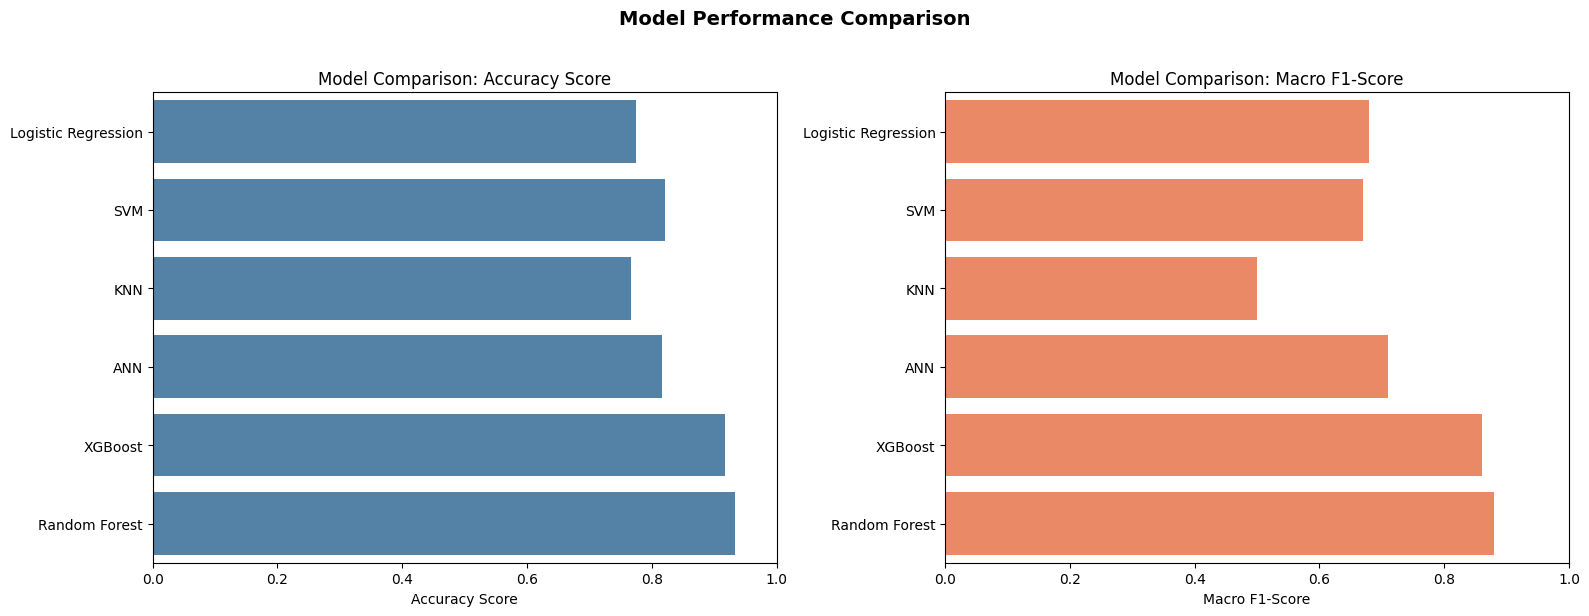

In [6]:
models = ['Logistic Regression', 'SVM', 'KNN', 'ANN', 'XGBoost', 'Random Forest']
accuracy = [0.7750, 0.8208, 0.7667, 0.8167, 0.9167, 0.9333]
macro_f1 = [0.68, 0.67, 0.50, 0.71, 0.86, 0.88]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# accuracy Chart
sns.barplot(x=accuracy, y=models, color='steelblue', ax=axes[0])
axes[0].set_xlabel('Accuracy Score')
axes[0].set_title('Model Comparison: Accuracy Score')
axes[0].set_xlim(0, 1)

# macro f1 chart
sns.barplot(x=macro_f1, y=models, color='coral', ax=axes[1])
axes[1].set_xlabel('Macro F1-Score')
axes[1].set_title('Model Comparison: Macro F1-Score')
axes[1].set_xlim(0, 1)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Observations.
Random Forest leads on both metrics — an accuracy of 93.33% and a macro f1 of 0.88 — confirming it as the strongest model across all three performance classes, not just the majority one. KNN stands out on the macro f1 chart for the wrong reasons, with a score of just 0.50 revealing that its overall accuracy was largely an illusion driven by rating 3. XGBoost comes close to Random Forest on both charts but the gap, though small, is consistent and meaningful.


# Results and Conclusion
After training and evaluating six models, **Random Forest with GridSearchCV** came out clearly on top with **93.33% accuracy and a macro f1-score of 0.88**. What makes this number meaningful is that it is not carried by the majority class. The minority classes, rating 2 and rating 4, both showed strong and balanced precision and recall, which is exactly what this problem needs. Switching from SMOTE to cost-sensitive learning cleaned up the false positives that were dragging the earlier models down.


## Top 3 Factors Affecting Employee Performance
The correlation analysis pointed to three features that stand out above everything else:

1. Environment Satisfaction (0.41) — the strongest signal in the entire dataset. Employees who feel good about where they work consistently perform better. With a correlation of 0.41, it sits clearly ahead of every other feature, making the work environment the single most important factor in predicting performance at INX.
2. Last Salary Hike Percentage (0.36) — the second strongest predictor. Employees who received meaningful salary increases tended to have higher performance ratings. 
3. Years Since Last Promotion (-0.17) — the strongest negative signal in the dataset. The longer an employee goes without a promotion, the lower their performance rating tends to be. Career stagnation is a real and measurable drag on output at INX.
Work Life Balance does show a positive correlation of 0.124, but I chose Years Since Last Promotion as the third factor because its signal of -0.17 is stronger, and it connects directly to the stagnation problem already visible in Finance and Sales.


# Business Recommendations
The analysis points to three areas INX can realistically act on:
1. Invest in the work environment, especially in Finance and Sales. Environment satisfaction was the single biggest driver of performance in this dataset, and Finance and Sales are the two departments with the lowest average performance ratings. Improving how employees feel about their environment results to better performance.
2. The data showed that top performers receive salary hikes between 20-22% while average and struggling employees sit around 14%. INX should check whether Finance and Sales employees are receiving comparable increases — because pay recognition and performance clearly move together.
3. Address promotion bottlenecks. The data shows that going years without a promotion negatively impacts performance. INX should identify employees who have been stuck in the same role for years, particularly in Finance and Sales, whether that means promoting them, moving them, or having an honest conversation about where they are headed.